In [ ]:
import pandas as pd
historical_url = "https://drive.google.com/uc?export=download&id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"
feargreed_url = "https://drive.google.com/uc?export=download&id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"
historical = pd.read_csv(historical_url)
feargreed = pd.read_csv(feargreed_url)
print(historical.head())
print(feargreed.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [ ]:
historical['Timestamp'] = pd.to_datetime(historical['Timestamp'], unit='ms')
historical['date'] = historical['Timestamp'].dt.date

# Convert fear/greed date
feargreed['date'] = pd.to_datetime(feargreed['date']).dt.date

# Merge datasets
merged = pd.merge(historical, feargreed, on='date', how='left')


In [ ]:
merged = merged.drop(columns=['Timestamp'])
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'date',
       'timestamp', 'value', 'classification'],
      dtype='object')


In [ ]:
print(merged.shape)
print(merged.columns)
print(merged.info())
print(merged.isnull().sum())

(211224, 19)
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'date',
       'timestamp', 'value', 'classification'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10 

In [ ]:
# Total PnL
total_pnl = merged['Closed PnL'].sum()

# Average PnL per trade
avg_pnl = merged['Closed PnL'].mean()

# Win rate
win_rate = (merged['Closed PnL'] > 0).mean()

print(total_pnl, avg_pnl, win_rate)

10296958.943436 48.74900079269401 0.4112648183918494


In [ ]:
merged.columns = merged.columns.str.strip()

In [ ]:
sentiment_perf = merged.groupby('classification')['Closed PnL'].agg(
    trades='count',
    avg_pnl='mean',
    total_pnl='sum'
)

print(sentiment_perf)

                trades    avg_pnl     total_pnl
classification                                 
Extreme Greed     6962  25.418772  1.769655e+05
Fear            133871  50.047622  6.699925e+06
Greed            36289  87.894859  3.189617e+06
Neutral           7141  22.229713  1.587424e+05


In [ ]:
side_analysis = pd.crosstab(merged['classification'], merged['Side'])
print(side_analysis)

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


In [ ]:
trade_count = merged['classification'].value_counts()
print(trade_count)

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


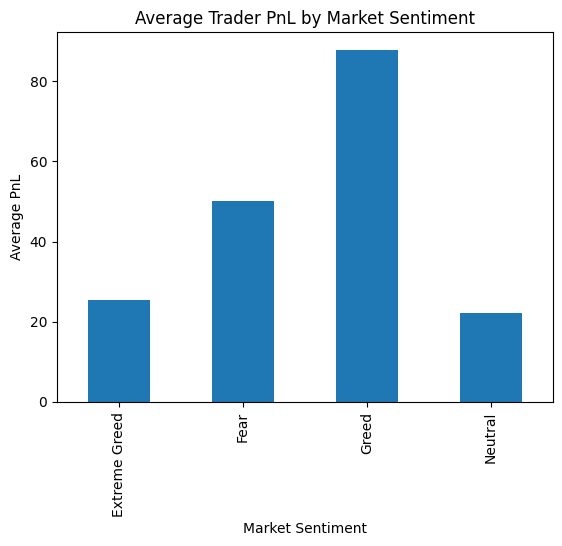

In [ ]:
import matplotlib.pyplot as plt

merged.groupby('classification')['Closed PnL'].mean().plot(kind='bar')

plt.title("Average Trader PnL by Market Sentiment")
plt.ylabel("Average PnL")
plt.xlabel("Market Sentiment")

plt.show()